### Intsall all dependencies (Ubuntu)

###### Install these from root terminal
```bash
apt-get update > /dev/null
apt install tesseract-ocr
```

In [50]:
!pip install transformers
!pip install torch
!pip install pytesseract
!pip install timm
!pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Defaulting to user installation because normal site-packages is not writeable
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Defaulting to user installation because normal site-packages is not writeable
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Defaulting to user installation because normal site-packages is not writeable


### Import all dependencies for LayoutLMv3

In [51]:
from PIL import Image, ImageDraw
from transformers import LayoutLMv3FeatureExtractor, LayoutLMv3ImageProcessor, LayoutLMv3TokenizerFast, LayoutLMv3Processor, LayoutLMv3ForSequenceClassification
import numpy as np

In [52]:
input_image = Image.open('./assets/cash-memo.jpg').convert("RGB")
input_image_width, input_image_height = input_image.size

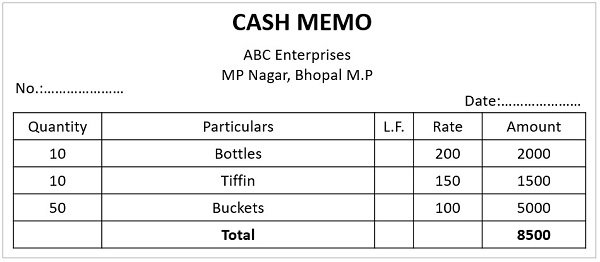

In [53]:
input_image

In [54]:
layoutlm_feature_extractor = LayoutLMv3FeatureExtractor(apply_ocr=True, ocr_lang="eng")
layoutlm_image_processor =  LayoutLMv3ImageProcessor(apply_ocr=True, ocr_lang="eng")
layoutlm_tokenizer = LayoutLMv3TokenizerFast.from_pretrained("microsoft/layoutlmv3-base")
layoutlm_processor = LayoutLMv3Processor(layoutlm_feature_extractor, layoutlm_tokenizer)

/home/onyx/.local/lib/python3.10/site-packages/transformers/models/layoutlmv3/feature_extraction_layoutlmv3.py:30: FutureWarning: The class LayoutLMv3FeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use LayoutLMv3ImageProcessor instead.
  warnings.warn(


In [55]:
layoutlm_processor_encoding = layoutlm_processor(
    input_image,
    max_length = 512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt"
)

layoutlm_processor_encoding.keys()

dict_keys(['input_ids', 'attention_mask', 'bbox', 'pixel_values'])

In [56]:
print(f"""
input_ids:  { list(layoutlm_processor_encoding["input_ids"].squeeze().shape) }
word boxes: { list(layoutlm_processor_encoding["bbox"].squeeze().shape) }
image data: { list(layoutlm_processor_encoding["pixel_values"].squeeze().shape) }
image size: { input_image.size }
""")


input_ids:  [512]
word boxes: [512, 4]
image data: [3, 224, 224]
image size: (600, 262)



In [57]:
layoutlm_features = layoutlm_feature_extractor(input_image)
layoutlm_image = layoutlm_image_processor(input_image)

In [58]:
print(f"""
--- layoutlm_feature_extractor ---
image size: { layoutlm_features["pixel_values"][0].shape }
word count: { len(layoutlm_features["words"][0]) }
word boxes: { len(layoutlm_features["boxes"][0]) }
""")

print(f"""
--- layoutlm_image_processor ---
image size: { layoutlm_image["pixel_values"][0].shape }
word count: { len(layoutlm_image["words"][0]) }
word boxes: { len(layoutlm_image["boxes"][0]) }
""")


--- layoutlm_feature_extractor ---
image size: (3, 224, 224)
word count: 30
word boxes: 30


--- layoutlm_image_processor ---
image size: (3, 224, 224)
word count: 30
word boxes: 30



In [59]:
input_image_pixel_values = layoutlm_features["pixel_values"][0]
input_image_words = layoutlm_features["words"][0]
input_image_bounding_boxes = layoutlm_features["boxes"][0]

### Converting input_image_pixel_values into a usable image to see what the transformers sees (just for understanding)

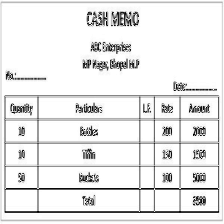

In [60]:

input_image_pixel_values = input_image_pixel_values.transpose(1, 2, 0)
input_image_pixel_values = np.uint8(input_image_pixel_values * 255)

Image.fromarray(input_image_pixel_values, mode="RGB")

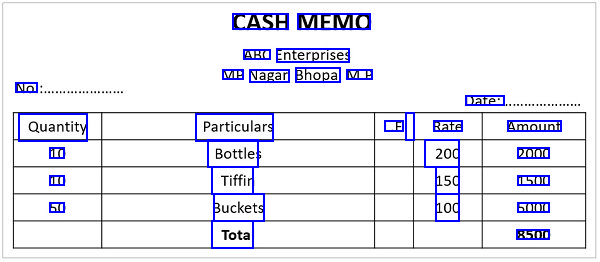

In [61]:
draw_image = input_image.copy()
width_scale = input_image_width / 1000
height_scale = input_image_height / 1000

draw = ImageDraw.Draw(draw_image)

for bbox in input_image_bounding_boxes:
  draw.rectangle(
      [
          bbox[0] * width_scale,
          bbox[1] * height_scale,
          bbox[2] * width_scale,
          bbox[3] * height_scale,
      ],
      outline = "blue",
      width = 2
  )

draw_image

In [62]:
layoutlm_tokenizer_encoding = layoutlm_tokenizer(
    text = input_image_words,
    boxes = input_image_bounding_boxes,
    max_length = 512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt"
)

In [63]:
input_image_tokens = layoutlm_tokenizer.convert_ids_to_tokens(
    layoutlm_tokenizer_encoding["input_ids"][0],
    skip_special_tokens=True
)

layoutlm_tokenizer.convert_tokens_to_string(input_image_tokens)

' CASH MEMO ABC Enterprises MP Nagar, Bhopal M.P No. Date:.. Quantity Particulars Lp | Rate Amount 10 Bottles 200 2000 10 Tiffin 150 1500 50 Buckets 100 5000 Total 8500'

In [64]:
from transformers import DetrFeatureExtractor, DetrImageProcessor, TableTransformerForObjectDetection
import torch
import matplotlib.pyplot as plt

In [85]:
detr_feature_extractor = DetrFeatureExtractor()
detr_image_processor = DetrImageProcessor()
detr_feature_extractor_encoding = detr_feature_extractor(input_image, return_tensors="pt")
detr_image_processor_encoding = detr_image_processor(input_image, return_tensors="pt")
detr_feature_extractor_encoding.keys()

dict_keys(['pixel_values', 'pixel_mask'])

In [88]:
table_detection_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-detection")

with torch.no_grad():
  outputs = table_detection_model(**detr_feature_extractor_encoding)

outputs.keys()

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])

In [96]:
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

def plot_results(pil_img, scores, labels, boxes, model):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for score, label, (xmin, ymin, xmax, ymax),c  in zip(scores.tolist(), labels.tolist(), boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        text = f'{model.config.id2label[label]}: {score:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

In [91]:
detr_feature_extractor

DetrFeatureExtractor {
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DetrFeatureExtractor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1333,
    "shortest_edge": 800
  }
}

In [68]:
results = detr_feature_extractor.post_process_object_detection(outputs, threshold=0.7, target_sizes=[(input_image_height, input_image_width)])[0]

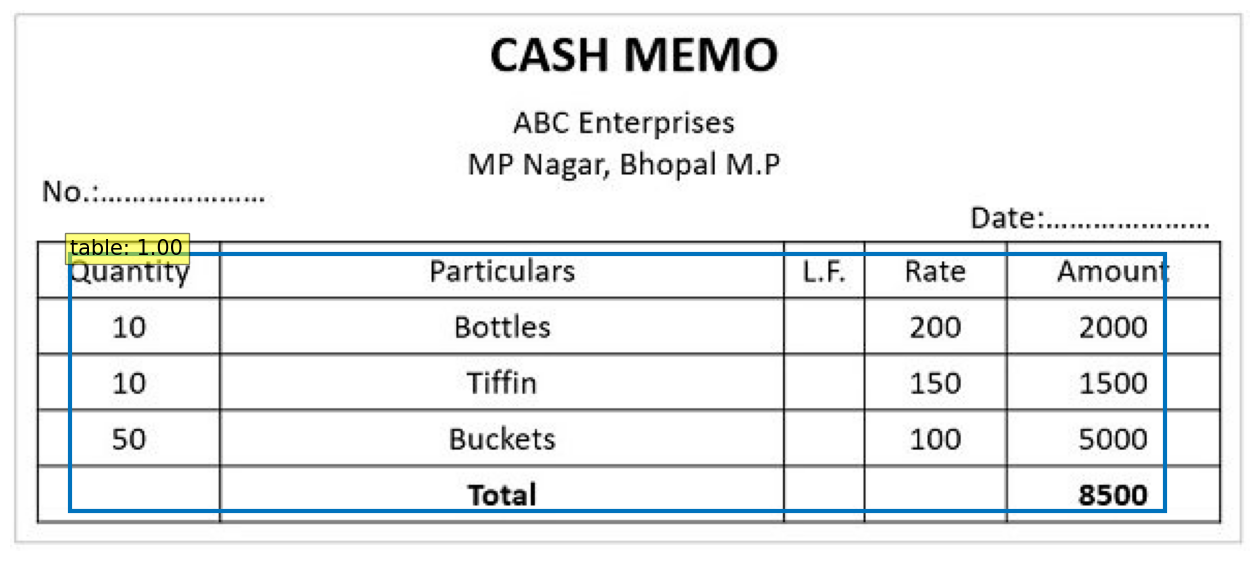

In [97]:
plot_results(input_image, results['scores'], results['labels'], results['boxes'], table_detection_model)

In [70]:
results

{'scores': tensor([0.9999]),
 'labels': tensor([0]),
 'boxes': tensor([[ 28.7408, 118.0281, 558.2628, 242.1310]])}

In [132]:
(xmin, ymin, xmax, ymax) = zip(results['boxes'][0].tolist())
table_image = input_image.crop((xmin[0] - 30, ymin[0] - 30, xmax[0] + 40, ymax[0] + 25))

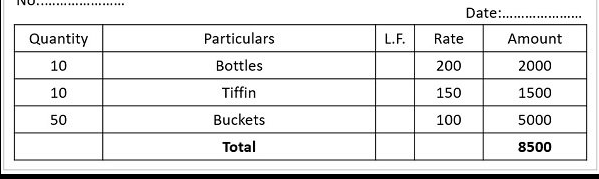

In [133]:
table_image

In [134]:
detr_table_feature_extractor_encoding = detr_feature_extractor(table_image, return_tensors="pt")
detr_table_feature_extractor_encoding.keys()

dict_keys(['pixel_values', 'pixel_mask'])

In [135]:
table_structure_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition")

with torch.no_grad():
  table_outputs = table_structure_model(**detr_table_feature_extractor_encoding)

table_outputs.keys()

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])

In [136]:
target_sizes = [table_image.size[::-1]]
table_results = detr_feature_extractor.post_process_object_detection(table_outputs, threshold=0.6, target_sizes=target_sizes)[0]
table_results

{'scores': tensor([0.9999, 0.9993, 0.9997, 0.9997, 1.0000, 0.9999, 0.9992, 0.9998, 0.9989,
         0.9884, 1.0000, 0.9806, 1.0000]),
 'labels': tensor([2, 1, 2, 1, 2, 2, 1, 1, 2, 3, 1, 5, 0]),
 'boxes': tensor([[ 27.9410, 106.0699, 560.5887, 133.7632],
         [340.8475,  28.9667, 418.3873, 156.2567],
         [ 27.9925,  52.1493, 560.8596,  79.4179],
         [ 27.8139,  29.0470, 142.9511, 156.2987],
         [ 27.8486,  78.9778, 560.7147, 106.6734],
         [ 28.0741,  28.8350, 560.8673,  52.0170],
         [418.9203,  28.9084, 483.0635, 156.3053],
         [483.5926,  28.9105, 560.9878, 156.3415],
         [ 28.1924, 133.5465, 560.3865, 156.3434],
         [ 27.9909,  28.7286, 560.8885,  51.8766],
         [143.5351,  28.8224, 331.6814, 156.3571],
         [ 28.0716, 105.1998, 142.4915, 155.8992],
         [ 28.1126,  28.8756, 560.7997, 156.2529]])}

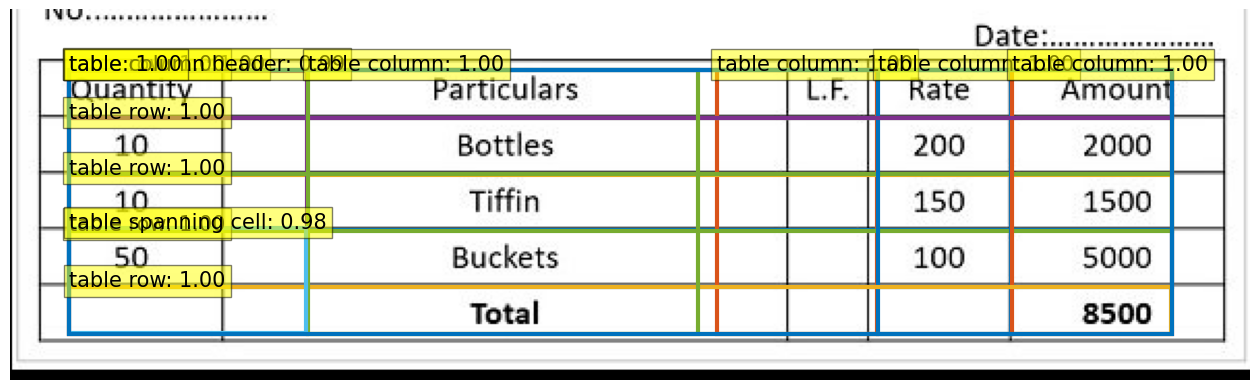

In [137]:
plot_results(table_image, table_results['scores'], table_results['labels'], table_results['boxes'], table_structure_model)

In [138]:
table_structure_model.config.id2label

{0: 'table',
 1: 'table column',
 2: 'table row',
 3: 'table column header',
 4: 'table projected row header',
 5: 'table spanning cell'}

### Columns

In [160]:
column_scores = list()
column_labels = list()
column_boxes = list()

table_scores = table_results['scores'].tolist()
table_labels = table_results['labels'].tolist()
table_boxes = table_results['boxes'].tolist()

for idx, label in enumerate(table_labels):
    if label == 1:
        column_scores.append(table_scores[idx])
        column_labels.append(label)
        column_boxes.append(table_boxes[idx])
    
column_scores = torch.tensor(column_scores)
column_labels = torch.tensor(column_labels)
column_boxes = torch.tensor(column_boxes)

In [161]:
column_scores

tensor([0.9993, 0.9997, 0.9992, 0.9998, 1.0000])

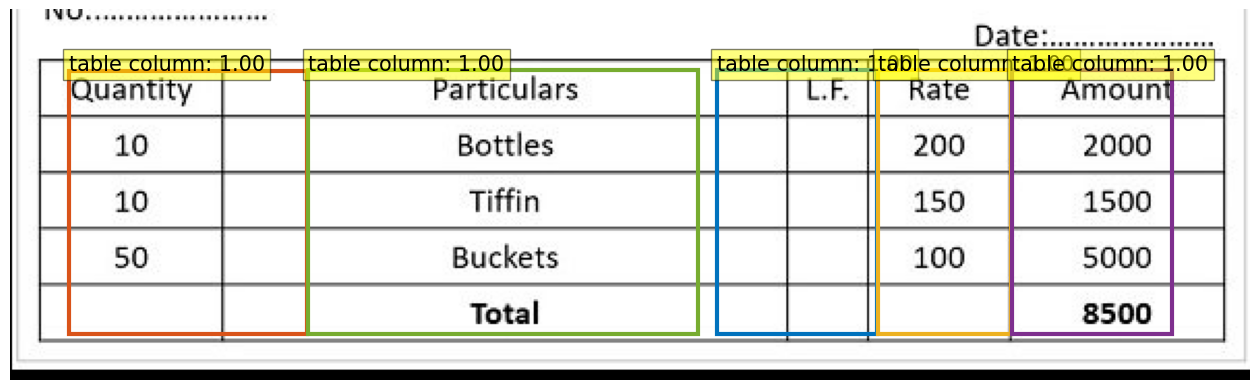

In [162]:
plot_results(table_image, column_scores, column_labels, column_boxes, table_structure_model)

### Rows

In [195]:
row_scores = list()
row_labels = list()
row_boxes = list()

table_scores = table_results['scores'].tolist()
table_labels = table_results['labels'].tolist()
table_boxes = table_results['boxes'].tolist()

for idx, label in enumerate(table_labels):
    if label == 2:
        row_scores.append(table_scores[idx])
        row_labels.append(label)
        row_boxes.append(table_boxes[idx])
    
row_scores = torch.tensor(row_scores)
row_labels = torch.tensor(row_labels)
row_boxes = torch.tensor(row_boxes)

[[27.941007614135742, 106.06991577148438, 560.5887451171875, 133.76319885253906], [27.992473602294922, 52.14927291870117, 560.859619140625, 79.41793823242188], [27.848588943481445, 78.97781372070312, 560.7146606445312, 106.67340850830078], [28.0740909576416, 28.83501625061035, 560.8673095703125, 52.016990661621094], [28.192428588867188, 133.5465087890625, 560.3865356445312, 156.34344482421875]]


In [193]:
print(row_boxes)

tensor([[ 27.9410, 106.0699, 560.5887, 133.7632],
        [ 27.9925,  52.1493, 560.8596,  79.4179],
        [ 27.8486,  78.9778, 560.7147, 106.6734],
        [ 28.0741,  28.8350, 560.8673,  52.0170],
        [ 28.1924, 133.5465, 560.3865, 156.3434]])


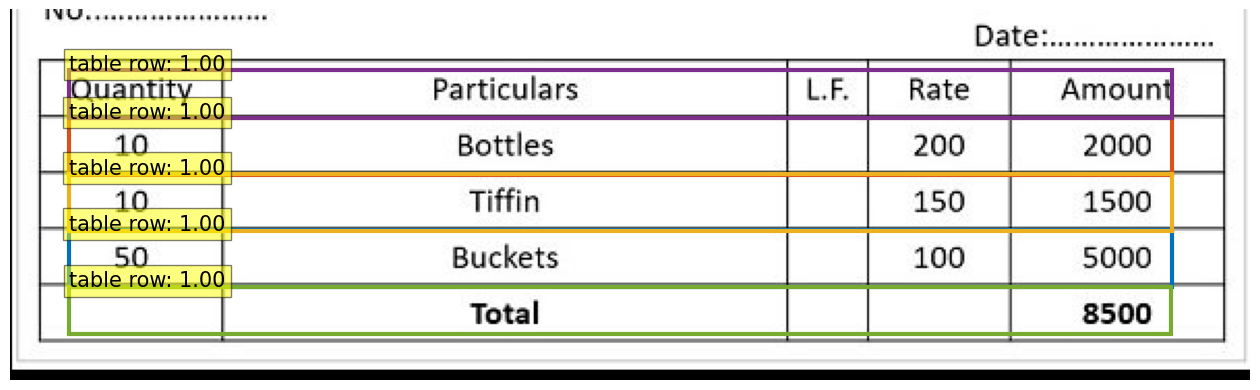

In [164]:
plot_results(table_image, row_scores, row_labels, row_boxes, table_structure_model)

# Attempting to get cells

In [199]:
rows = row_boxes.tolist()
columns = column_boxes.tolist()

cell_scores = list()
cell_labels = list()
cell_boxes = list()

for r in range(len(rows)):
    r_xmin = rows[r][0]
    r_ymin = rows[r][1]
    r_xmax = rows[r][2]
    r_ymax = rows[r][3]
    for c in range(len(columns)):
        c_xmin = columns[c][0]
        c_ymin = columns[c][1]
        c_xmax = columns[c][2]
        c_ymax = columns[c][3]
        
        n_xmin = max(r_xmin, c_xmin)
        n_ymin = max(r_ymin, c_ymin)
        n_xmax = min(r_xmax, c_xmax)
        n_ymax = min(r_ymax, c_ymax)
        
        cell_scores.append(0.99)
        cell_labels.append(1)
        cell_boxes.append([n_xmin, n_ymin, n_xmax, n_ymax])
        
print(cell_boxes)
        
cell_scores = torch.tensor(cell_scores)
cell_labels = torch.tensor(cell_labels)
cell_boxes = torch.tensor(cell_boxes)

[[340.8475341796875, 106.06991577148438, 418.38726806640625, 133.76319885253906], [27.941007614135742, 106.06991577148438, 142.95108032226562, 133.76319885253906], [418.9202575683594, 106.06991577148438, 483.0635070800781, 133.76319885253906], [483.59259033203125, 106.06991577148438, 560.5887451171875, 133.76319885253906], [143.53512573242188, 106.06991577148438, 331.6814270019531, 133.76319885253906], [340.8475341796875, 52.14927291870117, 418.38726806640625, 79.41793823242188], [27.992473602294922, 52.14927291870117, 142.95108032226562, 79.41793823242188], [418.9202575683594, 52.14927291870117, 483.0635070800781, 79.41793823242188], [483.59259033203125, 52.14927291870117, 560.859619140625, 79.41793823242188], [143.53512573242188, 52.14927291870117, 331.6814270019531, 79.41793823242188], [340.8475341796875, 78.97781372070312, 418.38726806640625, 106.67340850830078], [27.848588943481445, 78.97781372070312, 142.95108032226562, 106.67340850830078], [418.9202575683594, 78.97781372070312, 

In [200]:
print(cell_boxes)

tensor([[340.8475, 106.0699, 418.3873, 133.7632],
        [ 27.9410, 106.0699, 142.9511, 133.7632],
        [418.9203, 106.0699, 483.0635, 133.7632],
        [483.5926, 106.0699, 560.5887, 133.7632],
        [143.5351, 106.0699, 331.6814, 133.7632],
        [340.8475,  52.1493, 418.3873,  79.4179],
        [ 27.9925,  52.1493, 142.9511,  79.4179],
        [418.9203,  52.1493, 483.0635,  79.4179],
        [483.5926,  52.1493, 560.8596,  79.4179],
        [143.5351,  52.1493, 331.6814,  79.4179],
        [340.8475,  78.9778, 418.3873, 106.6734],
        [ 27.8486,  78.9778, 142.9511, 106.6734],
        [418.9203,  78.9778, 483.0635, 106.6734],
        [483.5926,  78.9778, 560.7147, 106.6734],
        [143.5351,  78.9778, 331.6814, 106.6734],
        [340.8475,  28.9667, 418.3873,  52.0170],
        [ 28.0741,  29.0470, 142.9511,  52.0170],
        [418.9203,  28.9084, 483.0635,  52.0170],
        [483.5926,  28.9105, 560.8673,  52.0170],
        [143.5351,  28.8350, 331.6814,  52.0170],


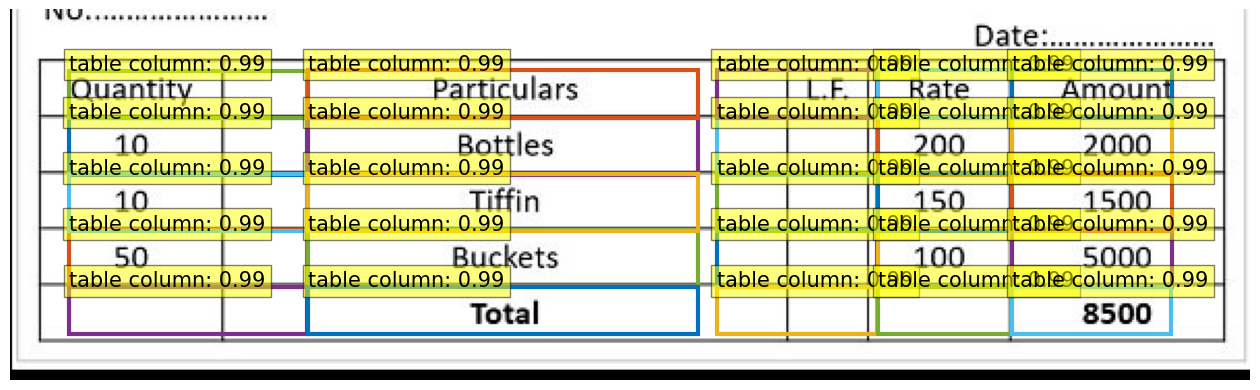

In [201]:
plot_results(table_image, cell_scores, cell_labels, cell_boxes, table_structure_model)